# Template Clustering Text
CSV -> bersihin teks -> TF-IDF -> KMeans -> evaluasi -> plot -> insight


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv("dataset.csv")                        # GANTI nama file
df = df.rename(columns={"Text Tweet": "corpus"})  # GANTI nama kolom teks
# df = df.sample(5000, random_state=42)   # kalau datanya gede, ambil sampel acak
df = df.dropna(subset="corpus").drop_duplicates(subset="corpus").reset_index(drop=True)
print(df.shape)
df.head()


(400, 5)


,Id,Sentiment,Acara TV,Jumlah Retweet,corpus
0,1,positive,HitamPutihTransTV,12,"Undang @N_ShaniJKT48 ke hitamputih, pemenang S..."
1,2,positive,HitamPutihTransTV,6,Selamat berbuka puasa Semoga amal ibadah hari ...
2,3,positive,HitamPutihTransTV,9,"Ada nih di trans7 hitam putih, dia dpt penghar..."
3,4,positive,HitamPutihTransTV,2,selamat ya mas @adietaufan masuk hitamputih
4,5,positive,HitamPutihTransTV,1,Asiknya nonton Hitam Putih Trans7


## Plot deskriptif


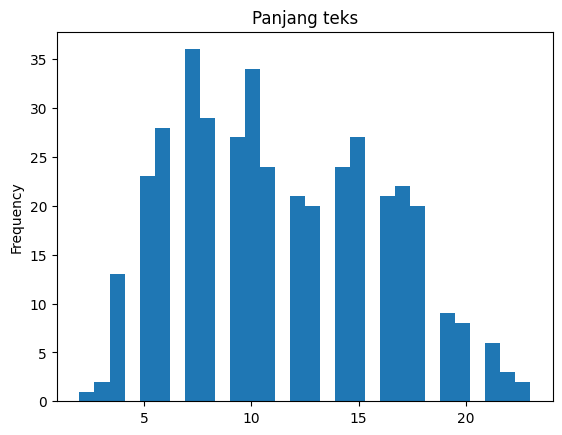

In [43]:
df["jumlah_kata"] = df["corpus"].str.split().str.len()
df["jumlah_kata"].plot(kind="hist", bins=30, title="Panjang teks")
plt.show()

# kalau ada kolom kategori
# df["kategori"].value_counts().plot(kind="bar")
# plt.show()


## Preprocessing


In [44]:
# Kalau belum terpasang, jalankan sekali:
# %pip install Sastrawi

from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Stemmer bahasa Indonesia
stemmer = StemmerFactory().create_stemmer()
stop = set(stopwords.words("indonesian"))   # GANTI "english" kalau bahasa inggris
stop.update(["yg", "ga", "gak", "aja", "banget", "nya"])

def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [w for w in text.split() if w not in stop]
    text = " ".join(words)
    text = stemmer.stem(text)  # STEMMING; beri # untuk menonaktifkan
    return text

df["cleaned"] = df["corpus"].apply(clean)

# Hapus teks yang kosong setelah cleaning dan stemming
df = df[df["cleaned"].str.strip().ne("")].reset_index(drop=True)
print("Jumlah data setelah cleaning:", len(df))
df[["corpus", "cleaned"]].head()


Jumlah data setelah cleaning: 400


,corpus,cleaned
0,"Undang @N_ShaniJKT48 ke hitamputih, pemenang S...",undang n shanijkt hitamputih menang ssk jkt mj...
1,Selamat berbuka puasa Semoga amal ibadah hari ...,selamat buka puasa moga amal ibadah ni terima ...
2,"Ada nih di trans7 hitam putih, dia dpt penghar...",nih trans hitam putih dpt harga norwegia hitam...
3,selamat ya mas @adietaufan masuk hitamputih,selamat ya mas adietaufan masuk hitamputih
4,Asiknya nonton Hitam Putih Trans7,asiknya nonton hitam putih trans


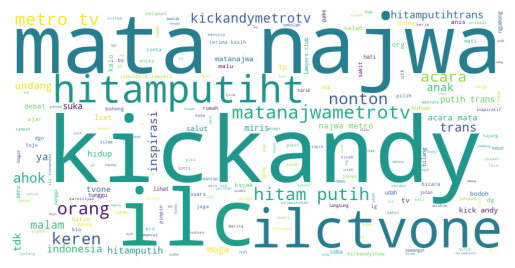

In [45]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(df["cleaned"]))
plt.imshow(wc)
plt.axis("off")
plt.show()


## TF-IDF


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(sublinear_tf=True, min_df=5, max_df=0.95)
X_tfidf = vectorizer.fit_transform(df["cleaned"])   # dipakai lagi buat top keywords
X = X_tfidf

X.shape


(400, 107)

## Tentukan k


  0%|          | 0/9 [00:00<?, ?it/s]

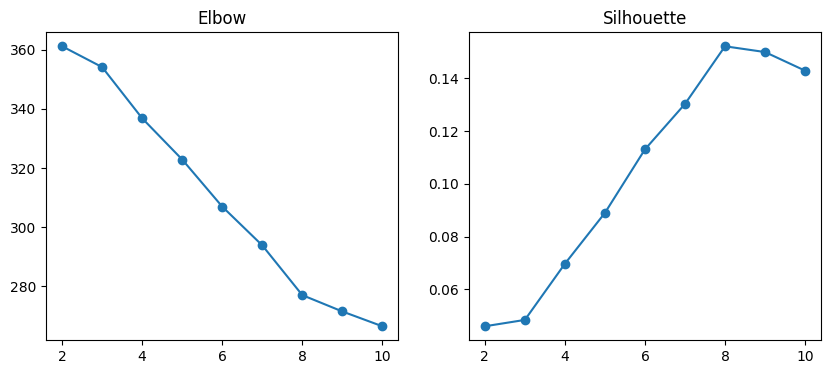

In [47]:
from tqdm.auto import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

ks = range(2, 11)
inertia, sil = [], []
for k in tqdm(ks):
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow")
ax[1].plot(ks, sil, "o-"); ax[1].set_title("Silhouette")
plt.show()


k dipilih = ... karena ... (isi sendiri dari grafik)

## KMeans + evaluasi


In [48]:
k = 8   # GANTI
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
df["cluster"] = kmeans.labels_

print("Silhouette    :", silhouette_score(X, df["cluster"]))
print("Davies-Bouldin:", davies_bouldin_score(X.toarray(), df["cluster"]))
# kalau pakai SVD: ganti X.toarray() jadi X
# print("Davies-Bouldin:", davies_bouldin_score(X, df["cluster"]))
print(df["cluster"].value_counts())


Silhouette    : 0.15217705575445956
Davies-Bouldin: 2.786224617847501
cluster
1    70
0    67
2    56
5    46
6    45
7    42
4    38
3    36
Name: count, dtype: int64


## Plot cluster (PCA)


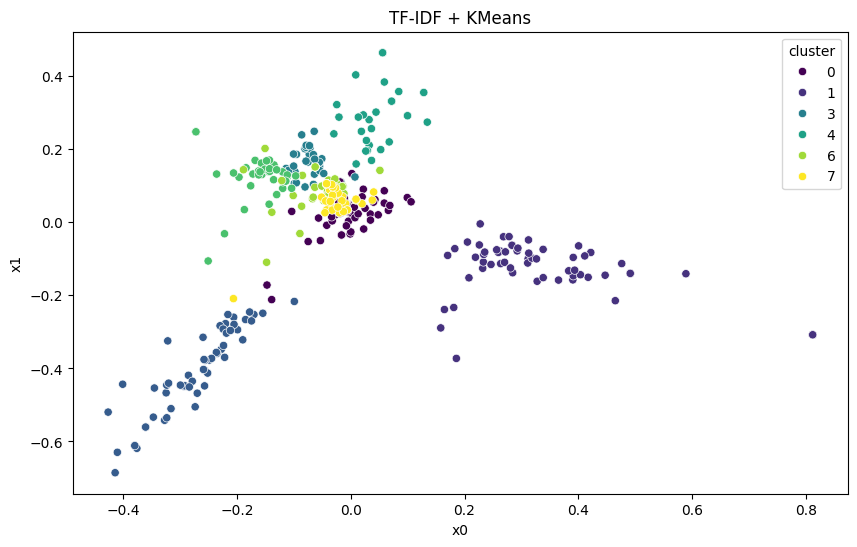

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X.toarray())
# kalau pakai SVD: pc = pca.fit_transform(X)
df["x0"], df["x1"] = pc[:, 0], pc[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="x0", y="x1", hue="cluster", palette="viridis")
plt.title("TF-IDF + KMeans")
plt.show()


## Insight tiap cluster


In [50]:
terms = vectorizer.get_feature_names_out()
centers = pd.DataFrame(X_tfidf.todense()).groupby(df["cluster"]).mean()

for c, row in centers.iterrows():
    top = [terms[i] for i in np.argsort(row)[-10:][::-1]]
    print(f"Cluster {c}: {', '.join(top)}")
    for t in df[df["cluster"] == c]["corpus"].head(3):
        print("   -", t)

# kalau ada kolom label
# pd.crosstab(df["cluster"], df["kategori"])


Cluster 0: kickandymetrotv, hitamputihtrans, indonesia, hitamputih, orang, andy, tdk, tvone, kick, trans
   - Undang @N_ShaniJKT48 ke hitamputih, pemenang SSK JKT48 harusnya mJKT48 ini lebih Layak di Undang karena prestasinya
   - Selamat berbuka puasa Semoga amal ibadah hari ni diterima Allah #hitamputih
   - selamat ya mas @adietaufan masuk hitamputih
Cluster 1: kickandy, orang, inspirasi, hidup, anak, coba, ahok, kickandyshow, agung, nonton
   - Kickandy gokil #kickandy
   - Terima kasih sudah menonton acara #kickandy eps ubah mimpimu jadi tindakan, semoga bermanfaat
   - Temukan lentera jiwamu #kickandy #mahasiswaum
Cluster 2: najwa, mata, tv, metro, acara, keren, nonton, anies, ahok, debat
   - Setuju. Al misbah, mata najwa dan kick andy program favorit
   - Metro_TV Mata Najwa: Pancasila Punya Kita http://metrotvn.ws/zNAj3qeb
   - Selera gue ini gatau akhir2 ini suka banget nonton metro tv kalo ga kick andy mata najwa, selera menua
Cluster 3: putih, hitam, trans, acara, undang, n

## Kesimpulan
- Evaluasi: silhouette = ..., DBI = ...
- Cluster 0: ...
- Cluster 1: ...
- Cluster 2: ...
